In [1]:
import pandas as pd
import jieba
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置字体为黑体以支持中文
plt.rcParams['axes.unicode_minus'] = False  # 解决负号'-'显示为方块的问题

In [2]:

# 加载BosonNLP情感词典
def load_boson_sentiment_dict(file_path):
    sentiment_dict = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                word, score = line.split()
                sentiment_dict[word] = float(score)
            except ValueError:
                print(f"无法处理的行: {line}")
    return sentiment_dict

In [4]:

# 加载其他词典
def load_word_list(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        return [line.strip() for line in f if line.strip()]

# 定义程度副词及其权重
degree_words = {
    '非常': 2.0,
    '极其': 2.0,
    '特别': 1.5,
    '相当': 1.5,
    '较': 1.2,
    '稍微': 0.8,
    '有点': 0.8,
    '略': 0.7,
}

# 加载情感词典和否定词典
sentiment_dict = load_boson_sentiment_dict('./dict/BosonNLP_sentiment_score.txt')
negation_words = load_word_list('./dict/negation_words.txt')  # 否定词典

In [5]:

# 读取CSV文件
def load_csv(column_name, file_path):
    df = pd.read_csv(file_path)
    return df[column_name].tolist()

# 情感分析函数
def analyze_sentiment(text, sentiment_dict, negation_words, degree_words):
    words = jieba.lcut(text)
    score = 0
    invert_flag = False  # 用于处理否定词
    degree = 1.0  # 强度因子，默认是1

    for i, word in enumerate(words):
        if word in negation_words:
            invert_flag = True  # 标记遇到否定词
        elif word in degree_words:
            degree = degree_words[word]  # 设置当前的强度因子
        elif word in sentiment_dict:
            current_score = sentiment_dict[word] * degree  # 应用强度因子
            if invert_flag:
                current_score = -current_score  # 反转情感极性
                invert_flag = False  # 重置否定标记
            score += current_score
            degree = 1.0  # 重置强度因子
        else:
            degree = 1.0  # 遇到非情感词时，重置强度因子
            invert_flag = False  # 如果遇到不相关词，重置否定标记

    return score

In [6]:

# 指定CSV文件路径和列名
csv_file_path = 'merged_output.csv'  # 替换为你的CSV文件路径
column_name = '弹幕信息'  # 替换为你想分析的列名

# 读取CSV文件中的指定列
texts = load_csv(column_name, csv_file_path)

# 对每个文本进行情感分析
results = []
for text in texts:
    score = analyze_sentiment(text, sentiment_dict, negation_words, degree_words)
    sentiment = '正面' if score > 0 else '负面' if score < 0 else '中性'
    results.append((text, sentiment, score))

# 创建新的DataFrame
results_df = pd.DataFrame(results, columns=['Text', 'Sentiment', 'Score'])

# 保存到CSV文件
output_csv_path = 'sentiment_analysis_results.csv'
results_df.to_csv(output_csv_path, index=False)
print(f"情感分析结果已保存到：{output_csv_path}")

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\Actor.D\AppData\Local\Temp\jieba.cache
Loading model cost 0.757 seconds.
Prefix dict has been built successfully.


情感分析结果已保存到：sentiment_analysis_results.csv


In [7]:

# 情感统计分析
sentiment_counts = results_df['Sentiment'].value_counts()
average_score = results_df['Score'].mean()
positive_count = results_df[results_df['Sentiment'] == '正面'].shape[0]
negative_count = results_df[results_df['Sentiment'] == '负面'].shape[0]
neutral_count = results_df[results_df['Sentiment'] == '中性'].shape[0]

# 输出结论
print(f"情感统计结果：")
print(f"正面情感数量：{positive_count}, 占比：{positive_count / len(results_df):.2%}")
print(f"负面情感数量：{negative_count}, 占比：{negative_count / len(results_df):.2%}")
print(f"中性情感数量：{neutral_count}, 占比：{neutral_count / len(results_df):.2%}")
print(f"平均情感得分：{average_score:.2f}")

if average_score > 0:
    print("总体情感倾向为正面。")
elif average_score < 0:
    print("总体情感倾向为负面。")
else:
    print("总体情感倾向为中性。")

情感统计结果：
正面情感数量：54328, 占比：54.55%
负面情感数量：40802, 占比：40.97%
中性情感数量：4460, 占比：4.48%
平均情感得分：0.47
总体情感倾向为正面。


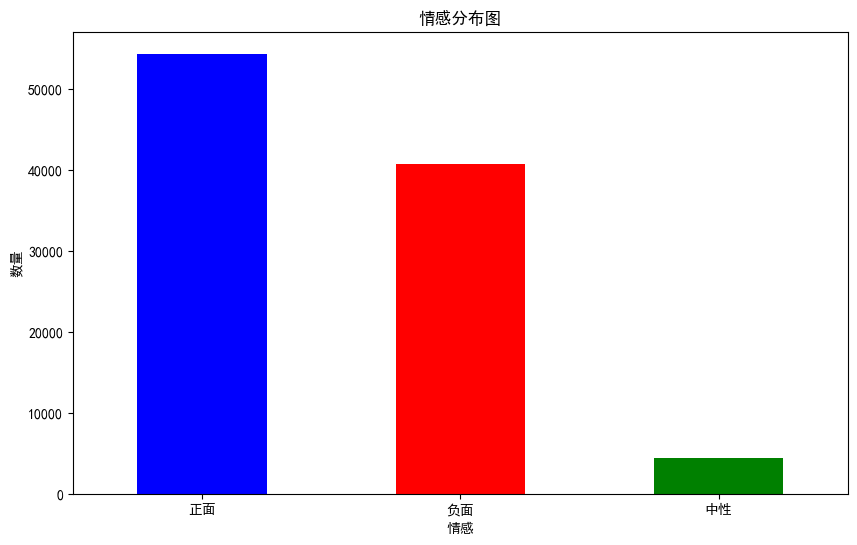

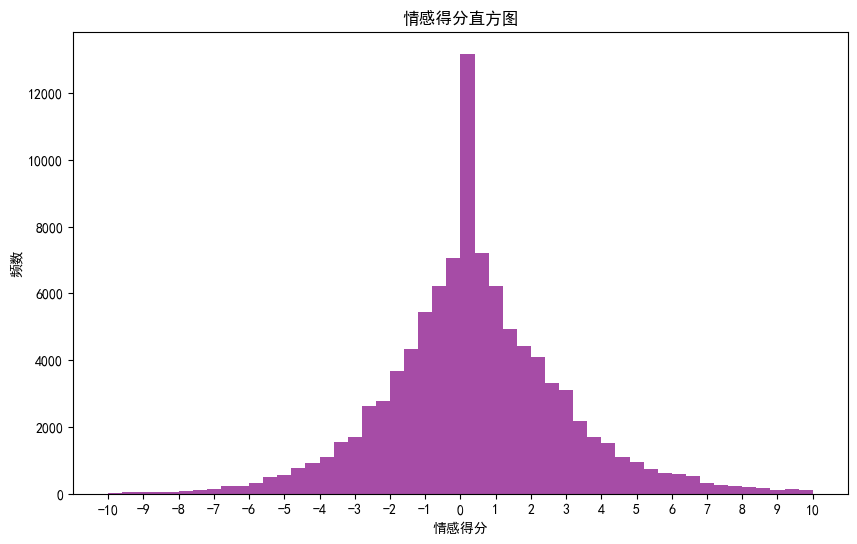

In [8]:

# 绘制情感分布图
plt.figure(figsize=(10, 6))
sentiment_counts.plot(kind='bar', color=['blue', 'red', 'green'])
plt.title('情感分布图')
plt.xlabel('情感')
plt.ylabel('数量')
plt.xticks(rotation=0)
plt.show()

# 绘制情感得分直方图
plt.figure(figsize=(10, 6))
plt.hist(results_df['Score'], bins=50 ,range=(-10, 10),color='purple', alpha=0.7)
plt.xticks(range(-10, 11, 1)) 
plt.title('情感得分直方图')
plt.xlabel('情感得分')
plt.ylabel('频数')
plt.show()